Original Data Shape: (56, 892)


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP transformed shape: (56, 3)


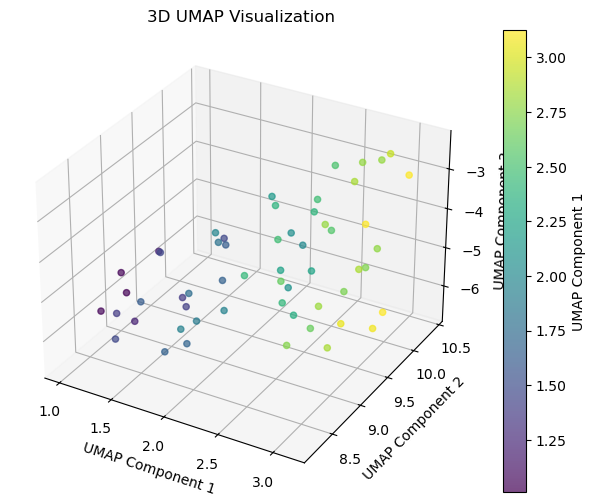

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import umap

# Load dataset
df = pd.read_csv("size_trials4.csv", header=None)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("Original Data Shape:", X_scaled.shape)

# Apply UMAP over all components
umap_model = umap.UMAP(n_components=3, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)
print("UMAP transformed shape:", X_umap.shape)

# Plot UMAP results in 3D space
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=X_umap[:, 0], cmap='viridis', alpha=0.7)
ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")
ax.set_zlabel("UMAP Component 3")
ax.set_title("3D UMAP Visualization")
plt.colorbar(sc, label="UMAP Component 1")
plt.show()


### K means after UMAP in 3D

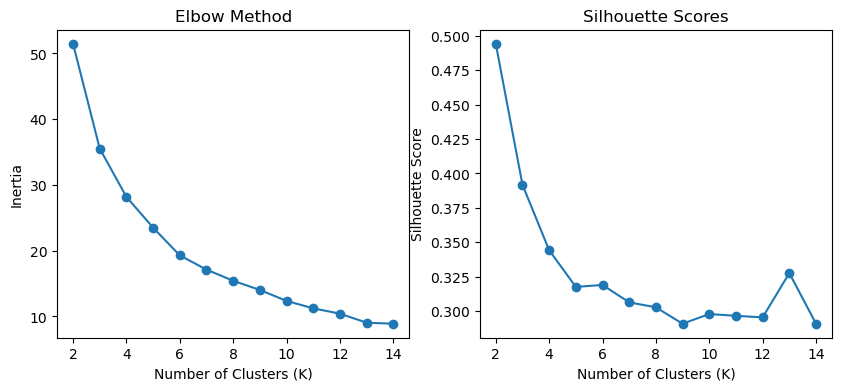

In [2]:
# Find optimal K using the Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 15)  # Test clusters from 2 to 14

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_umap)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_umap, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()

UMAP transformed shape: (56, 3)


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


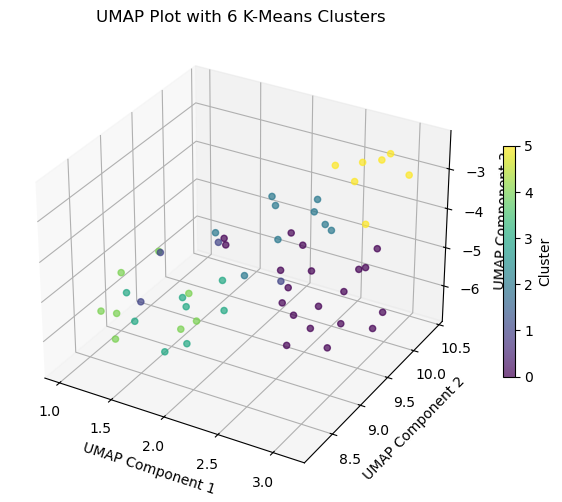

In [14]:
# Apply UMAP to reduce the dimensionality to 3D
umap_model = umap.UMAP(n_components=3, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)
print("UMAP transformed shape:", X_umap.shape)

# Apply K-Means clustering on the UMAP results
optimal_k = 6  # Choose the optimal number of clusters (could be determined using the elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_umap)

# Plot UMAP results with clusters in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=df['Cluster'], cmap='viridis', alpha=0.7)

# Add labels and title
ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")
ax.set_zlabel("UMAP Component 3")
ax.set_title(f"UMAP Plot with {optimal_k} K-Means Clusters")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()


### UMAP Component Reduction Labeled by Size in 3D

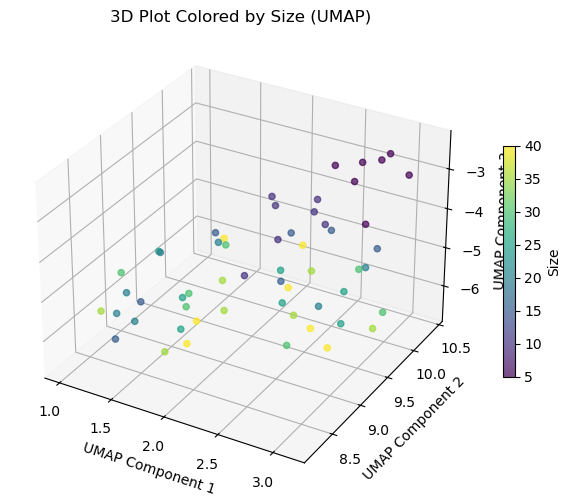

In [3]:
# 3D Plot of clusters colored by UMAP components
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

Sz = []
for i in range(56):
    Sz.append(((i % 8) * 5) + 5)

df['Size'] = Sz

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=df['Size'], cmap='viridis', alpha=0.7, zorder=1, depthshade=False)

# Labels and title
ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")
ax.set_zlabel("UMAP Component 3")
ax.set_title("3D Plot Colored by Size (UMAP)")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Size")

plt.show()


### K means after UMAP in 2D

UMAP transformed shape: (56, 2)


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


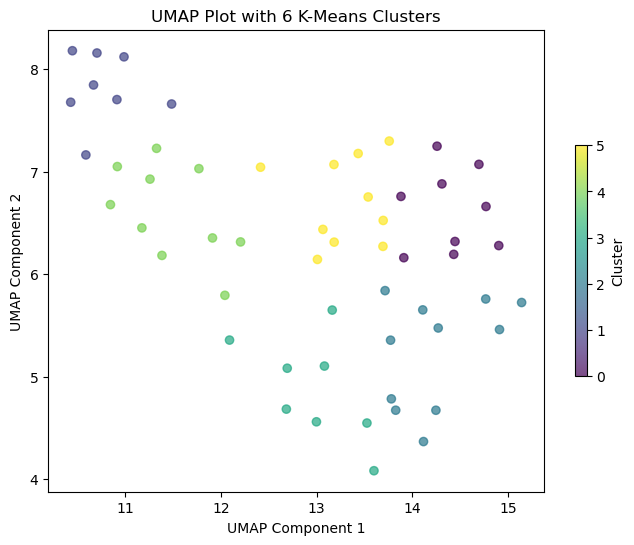

In [19]:
# Apply UMAP to reduce the dimensionality to 2D (or 3D)
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)
print("UMAP transformed shape:", X_umap.shape)

# Apply K-Means clustering on the UMAP results
optimal_k = 6  # Choose the optimal number of clusters (could be determined using the elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_umap)

# Plot UMAP results with clusters
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.7)

# Add labels and title
ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")
ax.set_title(f"UMAP Plot with {optimal_k} K-Means Clusters")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()


### UMAP Component Reduction Labeled by Size in 2D

UMAP transformed shape: (56, 2)


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


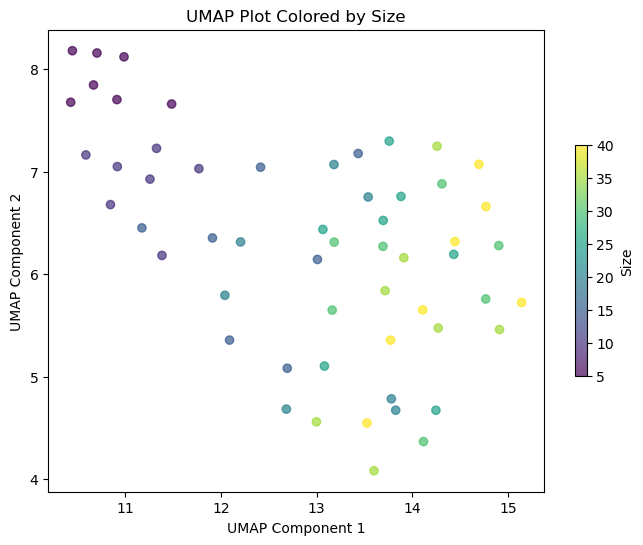

In [20]:
# Apply UMAP to reduce the dimensionality to 2D (or 3D)
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)
print("UMAP transformed shape:", X_umap.shape)

# Apply K-Means clustering on the UMAP results
optimal_k = 6  # Choose the optimal number of clusters (could be determined using the elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=2)
df['Cluster'] = kmeans.fit_predict(X_umap)

# Plot UMAP results with clusters
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=df['Size'], cmap='viridis', alpha=0.7)

# Add labels and title
ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")
ax.set_title("UMAP Plot Colored by Size")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Size")

plt.show()
